<a href="https://colab.research.google.com/github/irungus/Dessertation/blob/main/Final%20Desertatation%20Work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install catboost
!pip install lightgbm
!pip install missingno

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.3 MB/s eta 0:00:00


In [39]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_curve, precision_recall_curve, auc
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Classical ML
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier


# Boosting
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Imbalance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print("All Library Imported")

All Library Imported


In [4]:
# Define your file paths
url = 'https://raw.githubusercontent.com/irungus/Dessertation/main/Final_Data.csv'

print("Configuration setup complete!")

Configuration setup complete!


In [5]:
df = pd.read_csv(url)
print(f"Data loaded successfully! Shape: {df.shape}")
print("\nFirst few rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nSpecies distribution:")
print(df['species'].value_counts())

Data loaded successfully! Shape: (23660, 29)

First few rows:


,uid,species,latitude,longitude,occurrence,bio1,bio2,bio3,bio4,bio5,...,bio15,bio16,bio17,bio18,bio19,elevation,slope,aspect,hillshade,twi
0,6042,Acacia,-4.537429,39.139728,1,27.400000,9.0,64.699997,160.100006,34.500000,...,63.900002,539,142,174,192,74,0.614734,133.05743,0.699484,5.227901
1,5988,Eucalyptus,-4.522492,39.183680,1,27.600000,8.8,64.599998,159.800003,34.599998,...,66.900002,529,128,154,191,34,0.166116,142.69472,0.705072,10.077397
2,5985,Eucalyptus,-4.522487,39.183677,1,27.600000,8.8,64.599998,159.800003,34.599998,...,66.900002,529,128,154,191,34,0.166116,142.69472,0.705072,10.077397
3,5982,Eucalyptus,-4.522480,39.183657,1,27.600000,8.8,64.599998,159.800003,34.599998,...,66.900002,529,128,154,191,34,0.166116,142.69472,0.705072,10.077397
4,5932,Eucalyptus,-4.472281,39.189929,1,27.200001,8.9,65.199997,160.100006,34.200001,...,67.800003,559,137,166,190,96,0.950177,176.26205,0.698195,5.485536



Column names:
['uid', 'species', 'latitude', 'longitude', 'occurrence', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'elevation', 'slope', 'aspect', 'hillshade', 'twi']

Species distribution:
species
Grevillea     8659
Eucalyptus    5239
Musa          4924
Acacia        4838
Name: count, dtype: int64


In [6]:
# To drop a single column named 'column_name'
df = df.drop(columns=['uid'])

<Axes: >

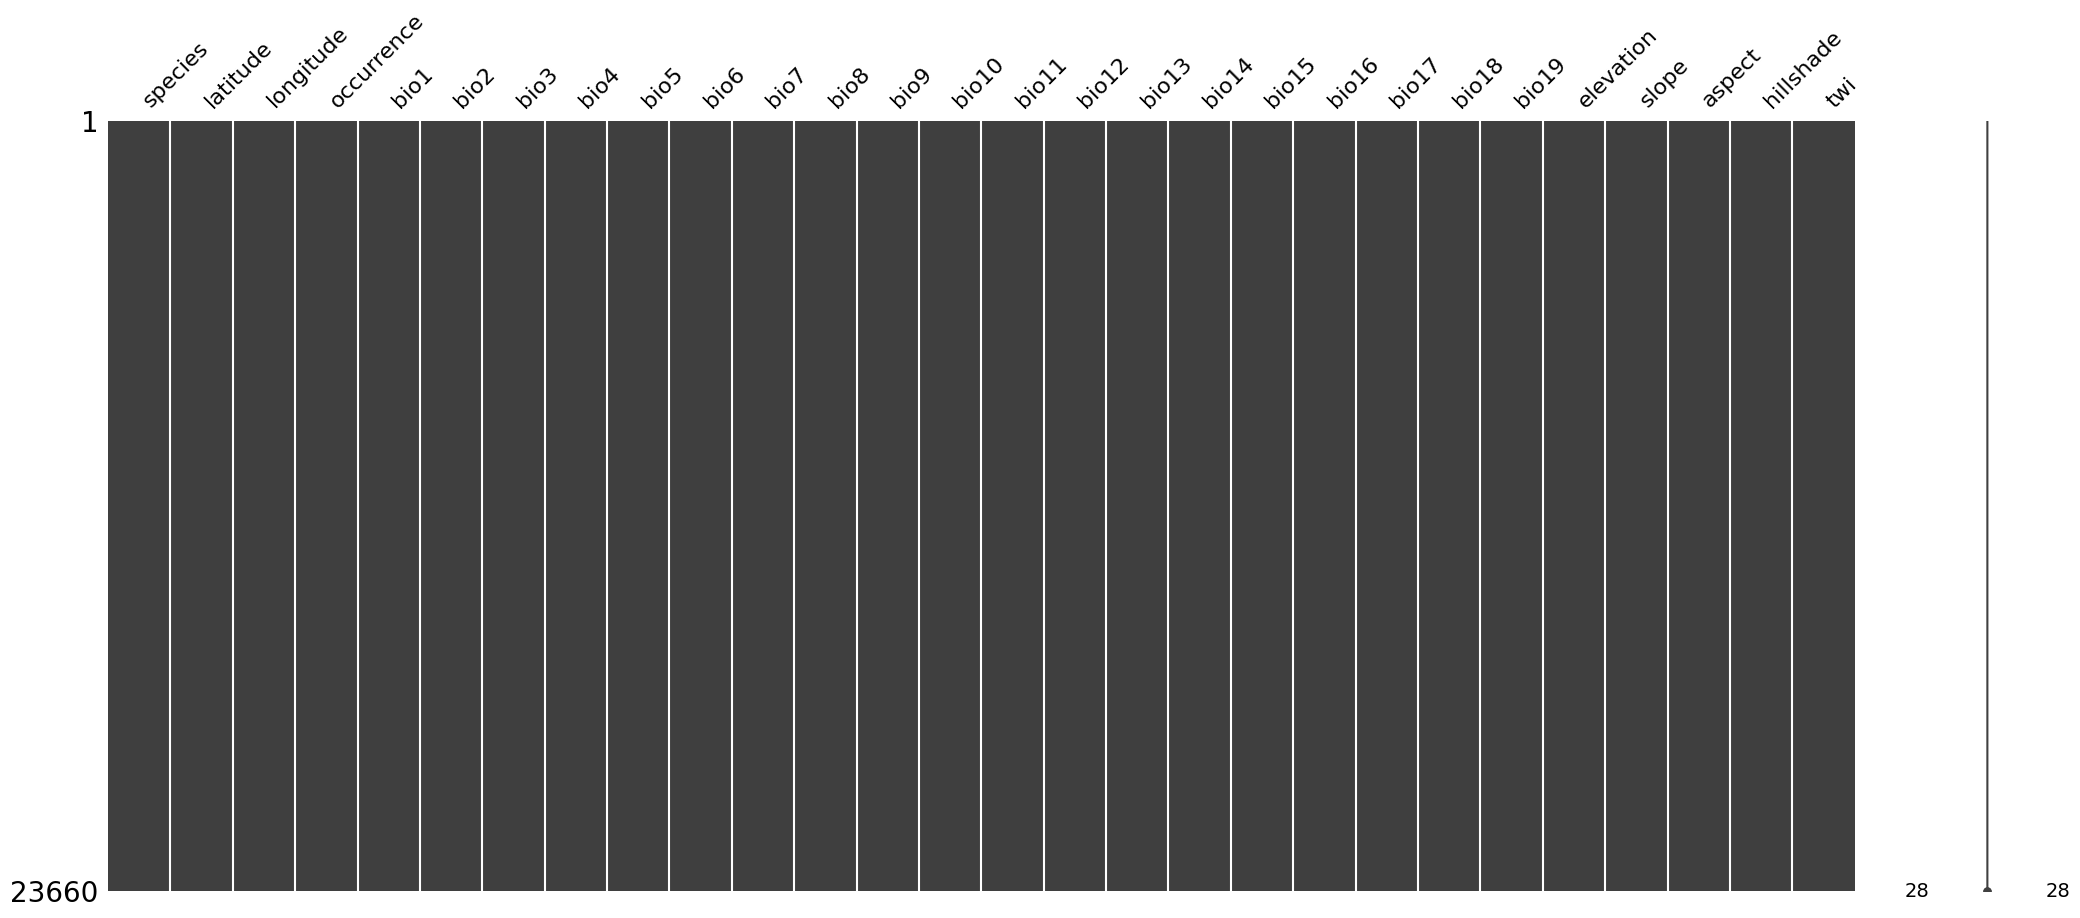

In [ ]:
#Check for missing values
msno.matrix(df)

In [ ]:
# Check for missing values in each column
missing_values_count = df.isnull().sum()

# Print the result
print("Number of missing values per column:")
print(missing_values_count)

Number of missing values per column:
species       0
latitude      0
longitude     0
occurrence    0
bio1          0
bio2          0
bio3          0
bio4          0
bio5          0
bio6          0
bio7          0
bio8          0
bio9          0
bio10         0
bio11         0
bio12         0
bio13         0
bio14         0
bio15         0
bio16         0
bio17         0
bio18         0
bio19         0
elevation     0
slope         0
aspect        0
hillshade     0
twi           0
dtype: int64


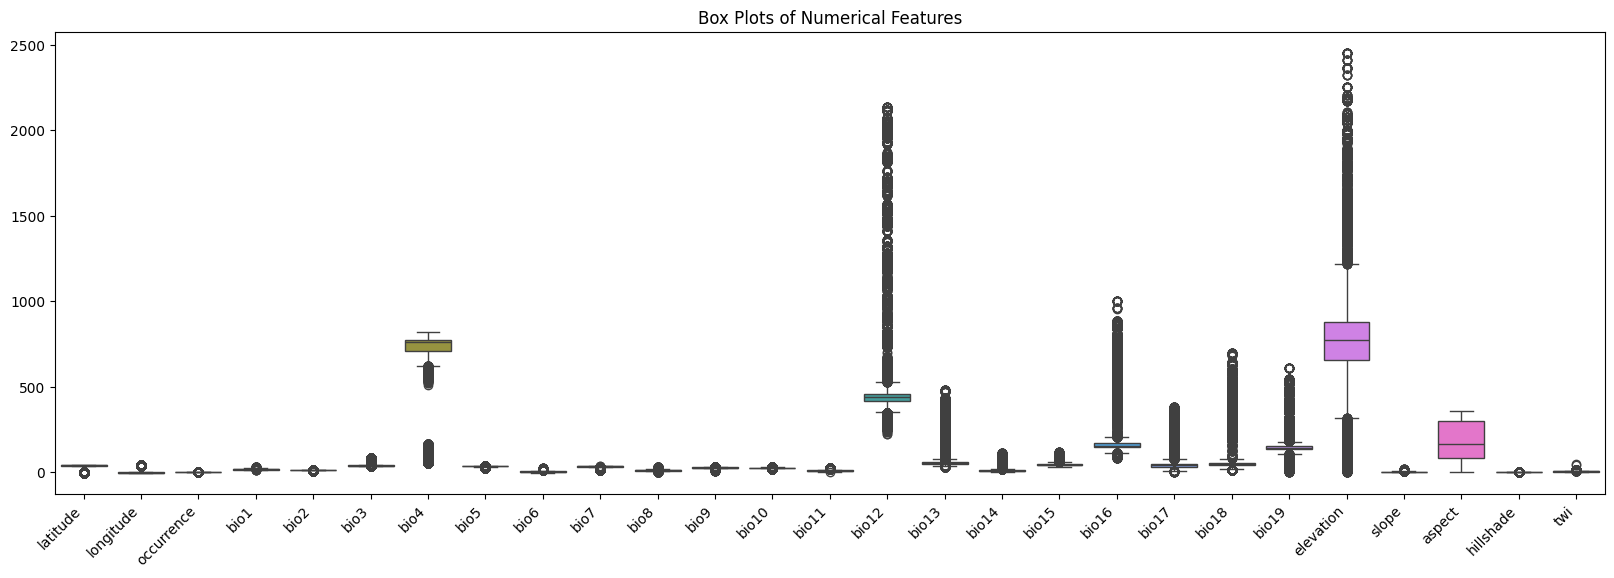

In [ ]:
#Check if there are outliers
plt.figure(figsize=(20, 6))
sns.boxplot(data=df)
plt.xticks(rotation=45, ha='right')
plt.title('Box Plots of Numerical Features')
plt.show()

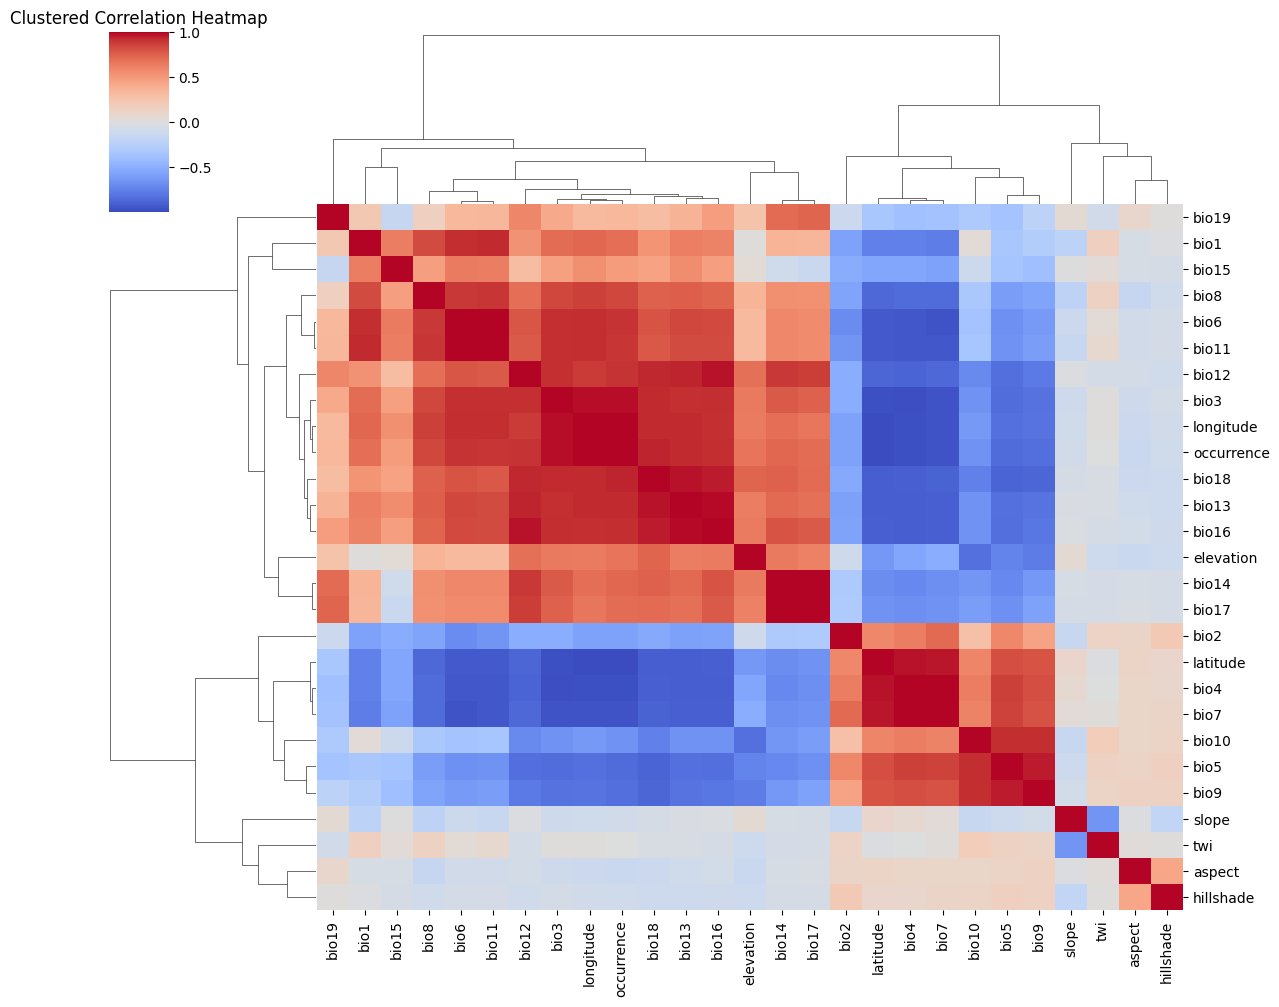

In [ ]:
# Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=np.number).columns
df_numeric = df[numeric_cols]

# Calculate the correlation matrix
correlation_matrix = df_numeric.corr()

sns.clustermap(correlation_matrix, cmap='coolwarm', figsize=(12, 10), annot=False)
plt.title('Clustered Correlation Heatmap')
plt.show()

In [ ]:
# 1. Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=np.number).columns
df_numeric = df[numeric_cols]

# 2. Calculate the correlation matrix
correlation_matrix = df_numeric.corr()

# 3. Unstack the correlation matrix to get a list of all pairs
# and sort them by absolute value
correlation_pairs = correlation_matrix.unstack().sort_values(kind="quicksort", ascending=False)

# 4. Filter for high correlations
# We'll filter for correlations that are above 0.7 (but not 1.0, which is self-correlation)
high_correlations = correlation_pairs[
    (correlation_pairs > 0.8) & (correlation_pairs < 1.0)
]
high_correlations.to_csv('high_correlations.csv')

In [7]:
# Get the unique species names
unique_species = df['species'].unique()

# Create a dictionary to store dataframes for each species
species_dfs = {}

# Iterate through unique species and create a dataframe for each
for species in unique_species:
    species_dfs[species] = df[df['species'] == species].copy()
    print(f"Created dataframe for {species} with shape: {species_dfs[species].shape}")

# You can now access each species dataframe like this:
acacia_df = species_dfs['Acacia']
eucalyptus_df = species_dfs['Eucalyptus']
grevillea_df = species_dfs['Grevillea']
musa_df = species_dfs['Musa']

Created dataframe for Acacia with shape: (4838, 28)
Created dataframe for Eucalyptus with shape: (5239, 28)
Created dataframe for Musa with shape: (4924, 28)
Created dataframe for Grevillea with shape: (8659, 28)


In [8]:
acacia_df.to_csv('acacia_df.csv')
eucalyptus_df.to_csv('eucalyptus_df.csv')
grevillea_df.to_csv('grevillea_df.csv')
musa_df.to_csv('musa_df.csv')

In [9]:
acacia_df.head()

,species,latitude,longitude,occurrence,bio1,bio2,bio3,bio4,bio5,bio6,...,bio15,bio16,bio17,bio18,bio19,elevation,slope,aspect,hillshade,twi
0,Acacia,-4.537429,39.139728,1,27.400000,9.0,64.699997,160.100006,34.500000,20.6,...,63.900002,539,142,174,192,74,0.614734,133.057430,0.699484,5.227901
15,Acacia,-4.000613,39.397586,1,26.299999,8.8,66.099998,149.800003,33.200001,19.9,...,51.599998,345,122,218,157,182,0.559727,33.576736,0.708441,5.321649
16,Acacia,-4.000612,39.397576,1,26.299999,8.8,66.099998,149.800003,33.200001,19.9,...,51.599998,345,122,218,157,182,0.559727,33.576736,0.708441,5.321649
17,Acacia,-4.000412,39.398595,1,26.299999,8.8,66.099998,149.800003,33.200001,19.9,...,51.599998,345,122,218,157,182,0.559727,33.576736,0.708441,5.321649
18,Acacia,-4.000398,39.398597,1,26.299999,8.8,66.099998,149.800003,33.200001,19.9,...,51.599998,345,122,218,157,182,0.559727,33.576736,0.708441,5.321649


In [12]:
acacia_df = acacia_df.drop(columns=['species'])

In [19]:
acacia_df.columns

Index(['latitude', 'longitude', 'occurrence', 'bio1', 'bio2', 'bio3', 'bio4',
       'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12',
       'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19',
       'elevation', 'slope', 'aspect', 'hillshade', 'twi'],
      dtype='object')

In [24]:
if "Unnamed: 0" in acacia_df.columns:
    acacia_df = acacia_df.drop(columns=["Unnamed: 0"])

In [25]:
acacia_df = acacia_df.drop_duplicates().reset_index(drop=True)

In [26]:
# Check for duplicate rows
duplicate_rows_count = acacia_df.duplicated().sum()

# Print the result
print(f"Number of duplicate rows: {duplicate_rows_count}")

Number of duplicate rows: 0


In [27]:
acacia_df.value_counts('occurrence')

,count
occurrence,
0,3839
1,999


In [28]:
TARGET = "occurrence"
if TARGET not in acacia_df.columns:
    raise ValueError(f"Target column '{TARGET}' not found in dataframe")

In [30]:
X = acacia_df.drop(columns=[TARGET])
y = acacia_df[TARGET].astype(int)

print("Dataset shape:", acacia_df.shape)
print("Class balance (original):")
print(y.value_counts())

Dataset shape: (4838, 27)
Class balance (original):
occurrence
0    3839
1     999
Name: count, dtype: int64


In [31]:
# 3) Train / Test split (stratified)
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
print("\nAfter split: train =", X_train.shape, " test =", X_test.shape)
print("Train class counts:", y_train.value_counts())


After split: train = (3386, 26)  test = (1452, 26)
Train class counts: occurrence
0    2687
1     699
Name: count, dtype: int64


In [34]:
# 4) Apply SMOTE to the TRAIN set only (no leakage)
# ------------------------------
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
print("After SMOTE (train) class counts:", pd.Series(y_resampled).value_counts())

After SMOTE (train) class counts: occurrence
1    2687
0    2687
Name: count, dtype: int64


In [40]:
# 5) Define models (scale where needed)
# ------------------------------
models = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=2000, random_state=42))]),
    "SVM (RBF)": Pipeline([("scaler", StandardScaler()), ("model", SVC(kernel="rbf", probability=True, random_state=42))]),
    "KNN": Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=5))]),
    "Naive Bayes": Pipeline([("scaler", StandardScaler()), ("model", GaussianNB())]),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05, use_label_encoder=False, eval_metric="logloss", n_jobs=-1, random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=300, learning_rate=0.05, n_jobs=-1, random_state=42),
    "CatBoost": CatBoostClassifier(iterations=300, learning_rate=0.05, depth=6, verbose=0, random_state=42),
}

In [41]:
# 6) Train each model separately, evaluate on HOLD-OUT TEST
# ------------------------------
results = []
roc_curves = []
pr_curves = []

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    # fit on SMOTE-resampled train
    model.fit(X_resampled, y_resampled)

    # predictions on true test set (unseen)
    # get probabilities (if available) for ROC/PR
    try:
        y_proba = model.predict_proba(X_test)[:, 1]
    except Exception:
        # fallback to decision_function if no predict_proba
        try:
            dfun = model.decision_function(X_test)
            # scale to [0,1]
            y_proba = (dfun - dfun.min()) / (dfun.max() - dfun.min() + 1e-9)
        except Exception:
            # last resort: use predictions as probabilities (not ideal)
            y_proba = model.predict(X_test)

    y_pred = model.predict(X_test)

    # metrics
    roc_auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"ROC-AUC: {roc_auc:.4f} | F1: {f1:.3f} | Precision: {prec:.3f} | Recall: {rec:.3f}")
    print("Confusion matrix:\n", cm)

    results.append({
        "Model": name,
        "ROC-AUC": roc_auc,
        "F1": f1,
        "Precision": prec,
        "Recall": rec
    })

    # store ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_curves.append((name, fpr, tpr, roc_auc))

    # store PR curve
    pr, rc, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(rc, pr)
    pr_curves.append((name, rc, pr, pr_auc))

# results DataFrame
results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)
print("\nFinal Results Table:")
print(results_df)



--- Training Logistic Regression ---
ROC-AUC: 1.0000 | F1: 1.000 | Precision: 1.000 | Recall: 1.000
Confusion matrix:
 [[1152    0]
 [   0  300]]

--- Training SVM (RBF) ---
ROC-AUC: 1.0000 | F1: 1.000 | Precision: 1.000 | Recall: 1.000
Confusion matrix:
 [[1152    0]
 [   0  300]]

--- Training KNN ---
ROC-AUC: 1.0000 | F1: 1.000 | Precision: 1.000 | Recall: 1.000
Confusion matrix:
 [[1152    0]
 [   0  300]]

--- Training Naive Bayes ---
ROC-AUC: 1.0000 | F1: 1.000 | Precision: 1.000 | Recall: 1.000
Confusion matrix:
 [[1152    0]
 [   0  300]]

--- Training Decision Tree ---
ROC-AUC: 1.0000 | F1: 1.000 | Precision: 1.000 | Recall: 1.000
Confusion matrix:
 [[1152    0]
 [   0  300]]

--- Training Random Forest ---
ROC-AUC: 1.0000 | F1: 1.000 | Precision: 1.000 | Recall: 1.000
Confusion matrix:
 [[1152    0]
 [   0  300]]

--- Training AdaBoost ---
ROC-AUC: 1.0000 | F1: 1.000 | Precision: 1.000 | Recall: 1.000
Confusion matrix:
 [[1152    0]
 [   0  300]]

--- Training XGBoost ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [02:42:33] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ROC-AUC: 0.9991 | F1: 0.997 | Precision: 0.993 | Recall: 1.000
Confusion matrix:
 [[1150    2]
 [   0  300]]

--- Training LightGBM ---
ROC-AUC: 1.0000 | F1: 1.000 | Precision: 1.000 | Recall: 1.000
Confusion matrix:
 [[1152    0]
 [   0  300]]

--- Training CatBoost ---
ROC-AUC: 1.0000 | F1: 1.000 | Precision: 1.000 | Recall: 1.000
Confusion matrix:
 [[1152    0]
 [   0  300]]

Final Results Table:
                 Model   ROC-AUC        F1  Precision  Recall
0  Logistic Regression  1.000000  1.000000   1.000000     1.0
1            SVM (RBF)  1.000000  1.000000   1.000000     1.0
2                  KNN  1.000000  1.000000   1.000000     1.0
3          Naive Bayes  1.000000  1.000000   1.000000     1.0
4        Decision Tree  1.000000  1.000000   1.000000     1.0
5        Random Forest  1.000000  1.000000   1.000000     1.0
6             AdaBoost  1.000000  1.000000   1.000000     1.0
7             LightGBM  1.000000  1.000000   1.000000     1.0
8             CatBoost  1.000000  1.000

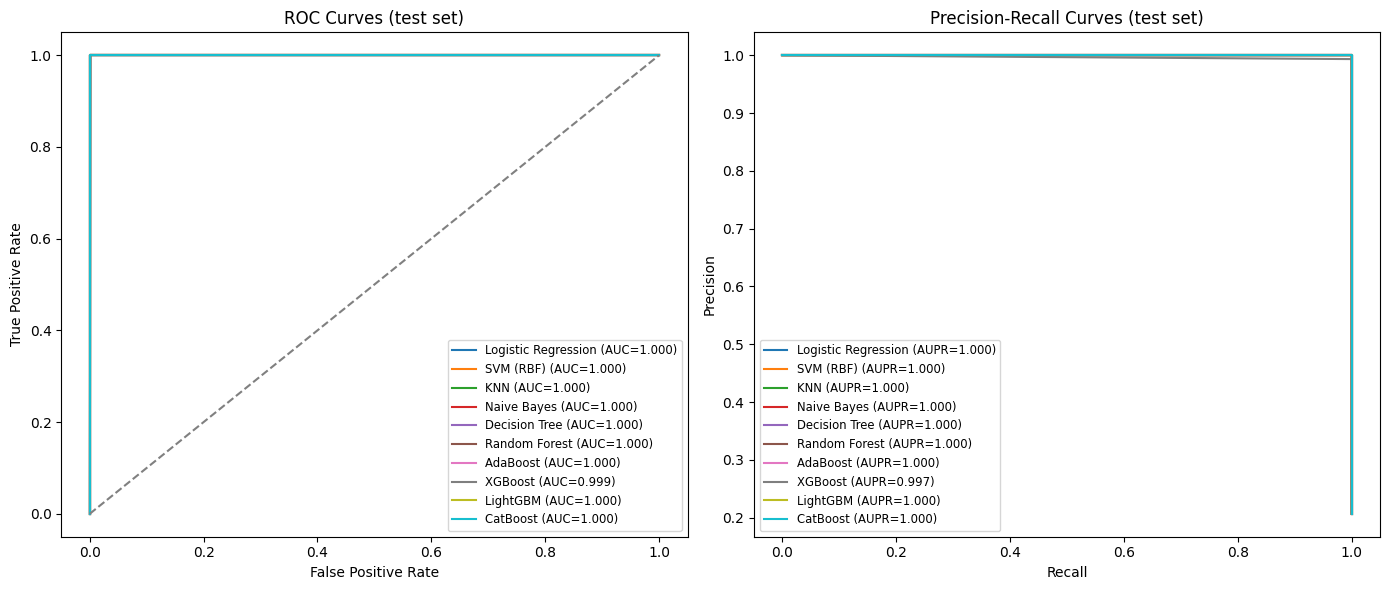

In [42]:
# 7) Plot ROC curves and Precision-Recall curves
# ------------------------------
plt.figure(figsize=(14,6))

# ROC plot
plt.subplot(1,2,1)
for name, fpr, tpr, roc_auc in roc_curves:
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1], linestyle="--", color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (test set)")
plt.legend(fontsize="small")

# PR plot
plt.subplot(1,2,2)
for name, rc, pr, pr_auc in pr_curves:
    plt.plot(rc, pr, label=f"{name} (AUPR={pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (test set)")
plt.legend(fontsize="small")

plt.tight_layout()
plt.show()

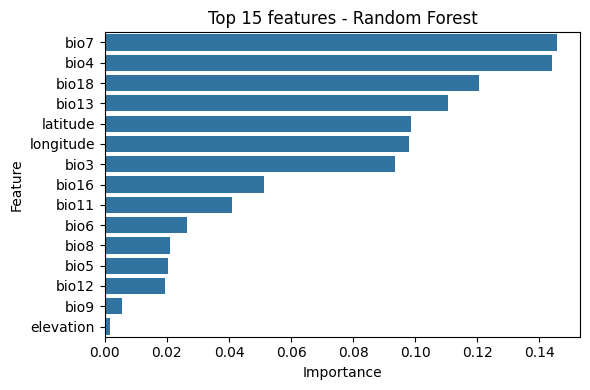


Top features for Random Forest:
       Feature  Importance
8        bio7    0.145797
5        bio4    0.144029
19      bio18    0.120706
14      bio13    0.110406
0    latitude    0.098594
1   longitude    0.097954
4        bio3    0.093419
17      bio16    0.051243
12      bio11    0.040865
7        bio6    0.026642
9        bio8    0.021014
6        bio5    0.020523
13      bio12    0.019543
10       bio9    0.005569
21  elevation    0.001786


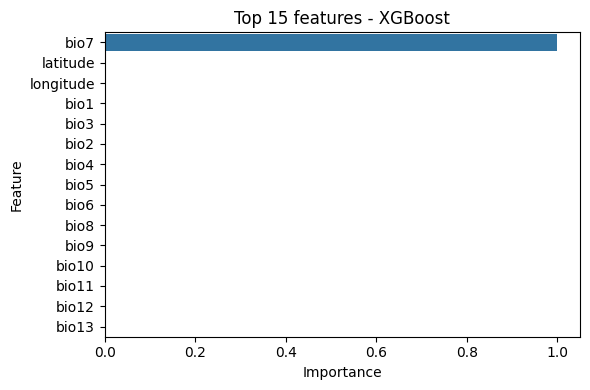


Top features for XGBoost:
       Feature  Importance
8        bio7         1.0
0    latitude         0.0
1   longitude         0.0
2        bio1         0.0
4        bio3         0.0
3        bio2         0.0
5        bio4         0.0
6        bio5         0.0
7        bio6         0.0
9        bio8         0.0
10       bio9         0.0
11      bio10         0.0
12      bio11         0.0
13      bio12         0.0
14      bio13         0.0


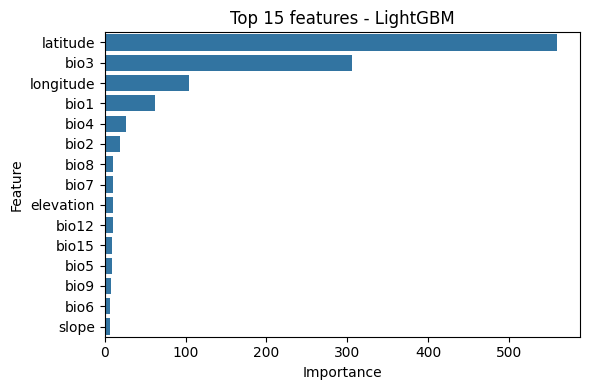


Top features for LightGBM:
       Feature  Importance
0    latitude         560
4        bio3         306
1   longitude         104
2        bio1          62
5        bio4          26
3        bio2          19
9        bio8          10
8        bio7          10
21  elevation          10
13      bio12          10
16      bio15           9
6        bio5           9
10       bio9           8
7        bio6           7
22      slope           7


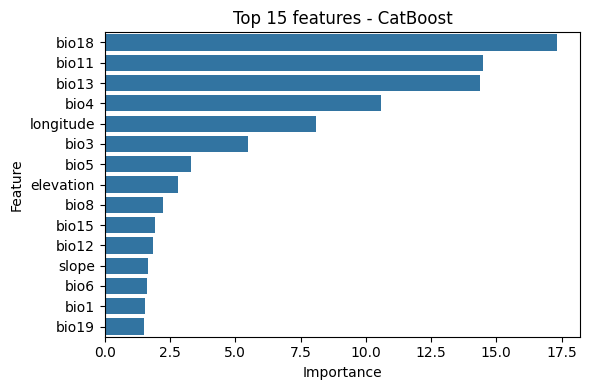


Top features for CatBoost:
       Feature  Importance
19      bio18   17.339717
12      bio11   14.493676
14      bio13   14.388195
5        bio4   10.563937
1   longitude    8.099162
4        bio3    5.505942
6        bio5    3.321694
21  elevation    2.788701
9        bio8    2.235642
16      bio15    1.910044
13      bio12    1.839035
22      slope    1.659603
7        bio6    1.616905
2        bio1    1.524970
20      bio19    1.514471


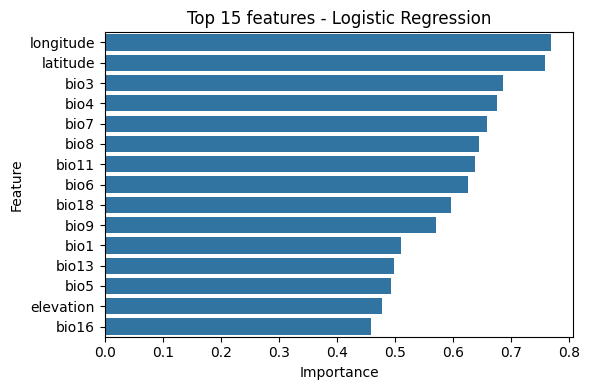


Top features for Logistic Regression:
       Feature  Importance
1   longitude    0.769157
0    latitude    0.759285
4        bio3    0.686384
5        bio4    0.676433
8        bio7    0.659335
9        bio8    0.644540
12      bio11    0.637590
7        bio6    0.626049
19      bio18    0.596077
10       bio9    0.570483
2        bio1    0.510247
14      bio13    0.498884
6        bio5    0.493314
21  elevation    0.478240
17      bio16    0.458752


In [44]:
# 8) Feature Importances / coefficients (interpretability)
# ------------------------------
def plot_top_features(name, model, X_columns, top_k=15):
    if name == "Logistic Regression":
        # model is a pipeline; get coefficients
        coef = model.named_steps["model"].coef_.ravel()
        fi = pd.DataFrame({"Feature": X_columns, "Importance": np.abs(coef)}).sort_values("Importance", ascending=False).head(top_k)
    elif name in ("Random Forest", "Decision Tree", "AdaBoost", "XGBoost", "LightGBM"):
        # all have feature_importances_
        importances = model.feature_importances_
        fi = pd.DataFrame({"Feature": X_columns, "Importance": importances}).sort_values("Importance", ascending=False).head(top_k)
    elif name == "CatBoost":
        importances = model.get_feature_importance()
        fi = pd.DataFrame({"Feature": X_columns, "Importance": importances}).sort_values("Importance", ascending=False).head(top_k)
    else:
        return None

    plt.figure(figsize=(6, max(4, 0.25*len(fi))))
    sns.barplot(x="Importance", y="Feature", data=fi, orient="h")
    plt.title(f"Top {len(fi)} features - {name}")
    plt.tight_layout()
    plt.show()
    return fi
    # plot for selected interpretable models:
for nm in ["Random Forest", "XGBoost", "LightGBM", "CatBoost", "Logistic Regression"]:
    if nm in models:
        fi_df = plot_top_features(nm, models[nm], X.columns, top_k=15)
        if fi_df is not None:
            print(f"\nTop features for {nm}:\n", fi_df)


In [45]:
# 9) (OPTIONAL) Cross-validate the best model with SMOTE inside CV
# ------------------------------
best_model_name = results_df.loc[0, "Model"]
print("\nBest model by holdout ROC-AUC:", best_model_name)

# Example: 5-fold stratified CV with SMOTE inside each split
from sklearn.model_selection import cross_val_score, StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_model = models[best_model_name]

# Build an imblearn pipeline: SMOTE -> scaler (if present) -> model
if isinstance(best_model, Pipeline):
    # separate scaler and model from the pipeline
    scaler = best_model.named_steps["scaler"]
    estimator = best_model.named_steps["model"]
    imb_pipe = ImbPipeline([("smote", SMOTE(random_state=42)), ("scaler", scaler), ("model", estimator)])
else:
    # no scaler needed; just SMOTE + estimator
    imb_pipe = ImbPipeline([("smote", SMOTE(random_state=42)), ("model", best_model)])

scores = cross_val_score(imb_pipe, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"\nCross-validated ROC-AUC for {best_model_name}: mean={scores.mean():.4f} ± std={scores.std():.4f}")


Best model by holdout ROC-AUC: Logistic Regression

Cross-validated ROC-AUC for Logistic Regression: mean=1.0000 ± std=0.0000
